# Predicting Data Science Job Salaries: Ridge Regression

The predictive task is to **predict data science job salaries based on job characteristics** such as experience level, job title, company size, and location.

This notebook builds, tunes, and evaluates the final Ridge Regression model.

Performance is assessed on a train-test split to measure generalization to unseen data.

## Data Loading

The dataset is reloaded here to ensure a clean and reproducible workflow. The data used is the same as in the EDA notebook.

In [1]:
# Upload dataset ZIP file to Google Colab
from google.colab import files
files.upload()
# upload the ZIP
!unzip archive.zip

Saving archive.zip to archive.zip
Archive:  archive.zip
  inflating: Data Science Jobs Salaries.csv  


In [2]:
# List extracted files
!ls

 archive.zip  'Data Science Jobs Salaries.csv'	 sample_data


## Importing Required Libraries

This section imports the Python libraries used for data manipulation, preprocessing, modeling, evaluation, and visualization throughout the analysis.

In [3]:
# Libraries for data handling
import pandas as pd
import numpy as np

# Libraries for model training and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

This section checks the first five rows to ensure that there is data.

In [4]:
df = pd.read_csv("Data Science Jobs Salaries.csv")
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021e,EN,FT,Data Science Consultant,54000,EUR,64369,DE,50,DE,L
1,2020,SE,FT,Data Scientist,60000,EUR,68428,GR,100,US,L
2,2021e,EX,FT,Head of Data Science,85000,USD,85000,RU,0,RU,M
3,2021e,EX,FT,Head of Data,230000,USD,230000,RU,50,RU,L
4,2021e,EN,FT,Machine Learning Engineer,125000,USD,125000,US,100,US,S
...,...,...,...,...,...,...,...,...,...,...,...
240,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
241,2021e,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
242,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
243,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


## Feature Selection

The target variable for this analysis is annual salary in USD. Predictor variables include job and company characteristics that are expected to influence compensation, such as experience level, employment type, job title, remote work ratio, company size, and company location.

In [5]:
# Define target variable
y = df["salary_in_usd"]

# Define feature matrix
X = df[
    [
        "experience_level",
        "employment_type",
        "job_title",
        "remote_ratio",
        "company_size",
        "company_location"
    ]
]

# Check dimensions
X.shape, y.shape

((245, 6), (245,))

## Data Preprocessing

Categorical features are one-hot encoded so that the models can interpret them numerically,
while numeric features are left unchanged.
This preprocessing is wrapped in a ColumnTransformer, which ensures consistent transformations
when used in model pipelines.

In [6]:
# Define categorical and numeric features
categorical_features = [
    "experience_level",
    "employment_type",
    "job_title",
    "company_size",
    "company_location"
]

numeric_features = ["remote_ratio"]

# Set up preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

## Train-Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.
Eighty percent of the data is used for training and twenty percent is reserved for testing.
A fixed random seed is used to ensure reproducibility.

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Ridge Regression Model

A Ridge Regression model is used as the final predictive model due to its strong performance and regularization properties.

The model's performance is evaluated on the test set using RMSE and R² metrics.

In [8]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]
)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

rmse_ridge, mae_ridge, r2_ridge

(np.float64(68909.7158050195), 40042.953260801725, 0.268931833580474)

## Predicted vs Actual Salaries

This scatter plot shows overall model fit, accuracy, and how well predictions track true values.

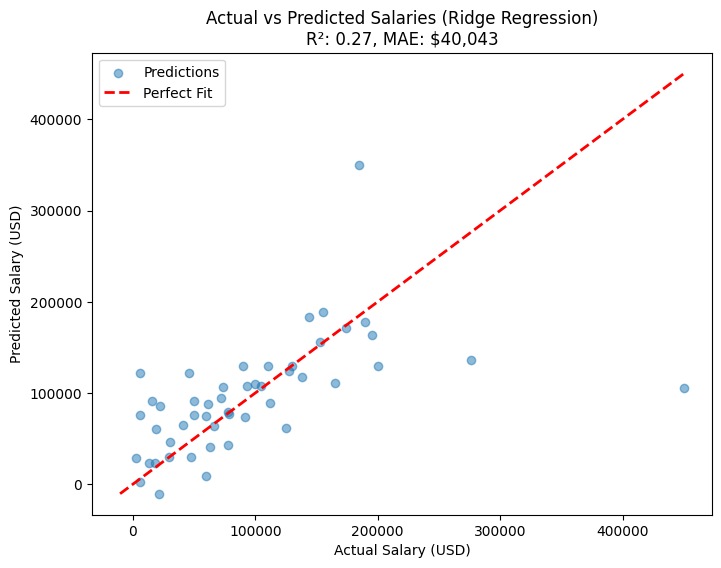

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, label='Predictions')

# Add a perfect prediction line (diagonal)
min_val = min(y_test.min(), y_pred_ridge.min())
max_val = max(y_test.max(), y_pred_ridge.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')

plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")
plt.title(f"Actual vs Predicted Salaries (Ridge Regression)\nR²: {r2_ridge:.2f}, MAE: ${mae_ridge:,.0f}")
plt.legend()
plt.show()

## Residual Distribution

The historgram shows the spread and skew of prediction errors, highlighting where the model over- or under-predicts.

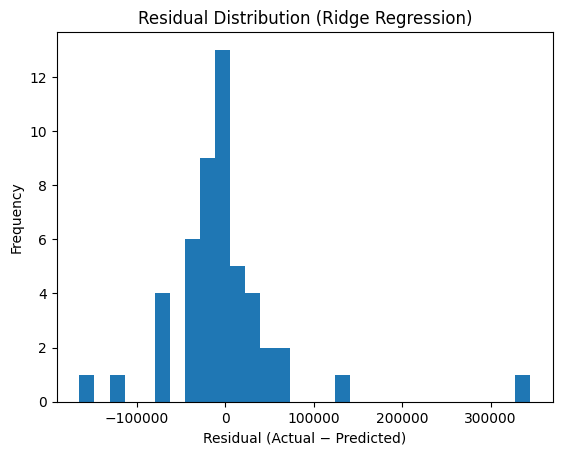

In [10]:
residuals = y_test - y_pred_ridge

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Ridge Regression)")
plt.show()

## Residuals vs Predicted

Residuals centered around zero indicate unbiased predictions. Patterns in the residuals may suggest areas where the model struggles.

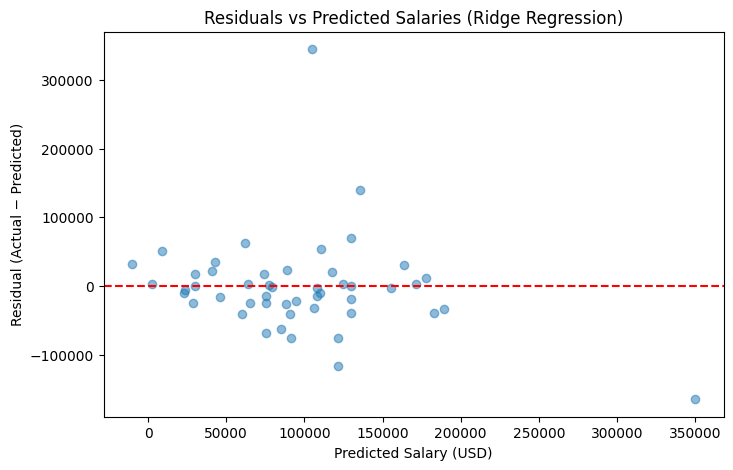

In [11]:
residuals = y_test - y_pred_ridge

plt.figure(figsize=(8,5))
plt.scatter(y_pred_ridge, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Salary (USD)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residuals vs Predicted Salaries (Ridge Regression)")
plt.show()

## Ridge Coefficients / Feature Importance

This section shows which features have the largest impact on predicted salaries.

Features with higher positive coefficients increase predicted salary, while negative coefficients decrease salary.
The following DataFrame and bar chart are based on the Ridge Regression model.

In [12]:
feature_names = ridge_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = ridge_model.named_steps["model"].coef_

feature_coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

feature_coefficient_df.head(10)

,feature,coefficient
44,cat__job_title_Principal Data Engineer,167172.220557
32,cat__job_title_Financial Data Analyst,145036.810752
11,cat__job_title_Applied Machine Learning Scientist,137284.132300
1,cat__experience_level_EX,75488.420803
41,cat__job_title_Machine Learning Scientist,68857.460139
86,cat__company_location_US,65873.329042
38,cat__job_title_ML Engineer,59816.154276
71,cat__company_location_JP,52062.246905
45,cat__job_title_Principal Data Scientist,49100.454128
4,cat__employment_type_CT,45600.160626


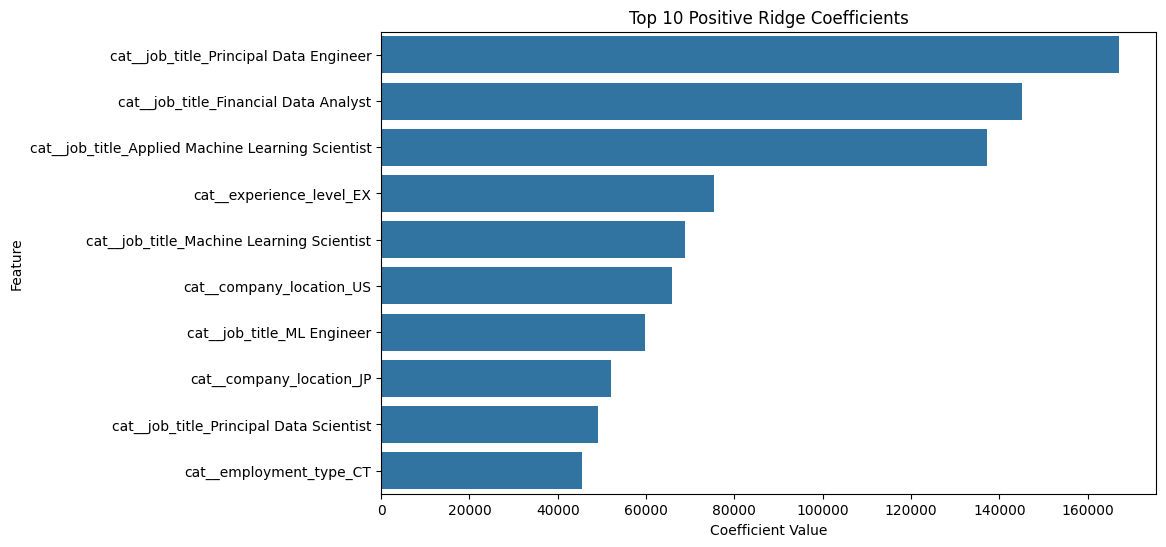

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x="coefficient", y="feature", data=feature_coefficient_df.head(10))
plt.title("Top 10 Positive Ridge Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

## Interpretation & Conclusion

### 1. Interpretation of Results

#### Model Performance
- **R² Score (~0.27)**: The model explains roughly 27% of the variability in salaries. This indicates a weak to moderate fit.
- **MAE (\$40,043)**: The average prediction error is around \$40,043, which is significant, especially for lower-paying roles.

#### Key Influencers (Feature Importance)
The bar chart of Ridge coefficients highlights the strongest salary drivers:
- **Job Title**: Specialized roles like *Principal Data Engineer* (+\$167k), *Financial Data Analyst* (+\$145k), and *Applied Machine Learning Scientist* (+\$137k) command the highest premiums.
- **Experience**: Executive-level roles (`EX`) add approximately **\$75,000** to the baseline.
- **Location**: US-based roles (`US`) are associated with a **\$66,000** premium compared to the baseline.

#### Visual Diagnostics
- **Actual vs. Predicted**: The scatter plot shows that while the model captures the general trend for low-to-mid salaries, it struggles with high-salary outliers, where points drift below the diagonal (indicating underprediction).
- **Residual Distribution**: The histogram shows residuals centered near zero, indicating no massive systematic bias, but the long tails reflect the model's difficulty with extreme values.
- **Residuals vs. Predicted**: This plot reveals that while errors are generally centered around zero, the variance is not perfectly constant. There are distinct outliers at higher predicted values, suggesting that the model's precision decreases for higher-paying roles.

### 2. Conclusion

This analysis utilized Ridge Regression to identify key drivers of data science salaries.

*   **Key Findings**: Compensation is heavily influenced by **seniority** (Executive level), **specialized job titles**, and **location** (US-based companies pay significantly higher premiums).
*   **Model Limitations**: While the model successfully identifies these broad trends, the mean absolute error of \$40,043 suggests that a significant portion of salary variance remains unexplained by the current features.
*   **Future Work**: To build a more precise predictor, future iterations should incorporate more granular data, such as specific technical skills (e.g., Python, AWS, Spark), years of experience as a continuous variable, and educational background.